In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [3]:
class ProductState(TypedDict):
    price: float
    discount_percentage: float
    discount_amount: float
    tax_percent: float
    tax_amount: float
    discounted_price: float
    final_price: float


In [4]:
### Create workflow and graph
graph = StateGraph(ProductState)

In [6]:
### apply_discount
def apply_discount(state: ProductState):
    price = state["price"]
    disc_amt= state["price"] * (state["discount_percentage"]/100)

    disc_price = price-disc_amt

    return {"discount_amount":disc_amt,
            "discounted_price":disc_price}

In [7]:
### get_tax_rate
def get_tax_rate(state: ProductState):
    ## assume gst tax: 18%
    tax = 18
    return {"tax_percent":tax}

In [9]:
## calculate_tax_amount
def calculate_tax_amount(state: ProductState):
    tax_amount = (
        state["discounted_price"]
        * state["tax_rate"]
        / 100
    )

    return {"tax_amount":tax_amount}

In [26]:
## calculate_final_price
def calculate_final_price(state: ProductState):
    final_price = state["discounted_price"]+state["tax_amount"]
    return {"final_price":final_price}

In [27]:
### add nodes
graph.add_node("apply_discount",apply_discount)
graph.add_node("get_tax_rate",get_tax_rate)
graph.add_node("calculate_tax_amount",calculate_tax_amount)
graph.add_node("calculate_final_price",calculate_final_price)

Adding a node to a graph that has already been compiled. This will not be reflected in the compiled graph.


ValueError: Node `apply_discount` already present.

In [17]:
### add edges
graph.add_edge(START,"apply_discount")
graph.add_edge(START,"get_tax_rate")
graph.add_edge("get_tax_rate","calculate_tax_amount")
graph.add_edge("calculate_tax_amount","calculate_final_price")
graph.add_edge("apply_discount","calculate_final_price")
graph.add_edge("calculate_final_price",END)

Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


In [18]:
graph

In [28]:
app = graph.compile()

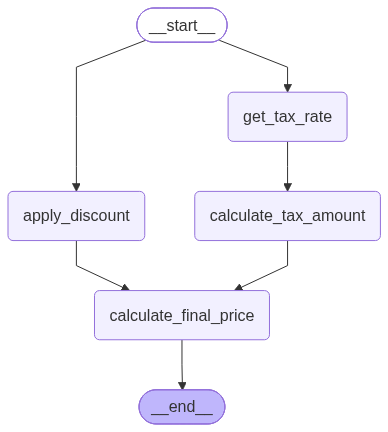

In [29]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [30]:
initial_state = {
    "price": 1000.0,
    "discount_percentage":10.0
}

In [31]:
final_state = app.invoke(initial_state)

KeyError: 'tax_amount'